# Smart CV Analyzer — 01: Data Preparation & EDA

**Course:** COMP6885001 — Natural Language Processing | BINUS University 2025/2026

Pipeline scope for this notebook:

| Notebook | Scope |
|----------|-------|
| **01 (this)** | Raw data loading, merging, exploratory analysis |
| 02 | Text preprocessing, NER, TF-IDF, skill extraction |
| 03 | Semantic matching, algorithm comparison, evaluation |

**Outputs:** `notebooks/data/processed/merged_resumes.csv`, `job_descriptions.csv`

In [1]:
import os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sys.path.append(os.path.abspath(os.path.join("..")))
print("Imports OK.")

Imports OK.


## 1. Dataset Loading

Set `PROJECT_ROOT` to the `AOL_NLP` root folder if paths are not resolved correctly.

In [2]:
PROJECT_ROOT       = os.path.abspath(os.path.join(os.getcwd(), ".."))
JOB_DESC_PATH      = os.path.join(PROJECT_ROOT, "data", "raw", "job_descriptions_bibek.csv")
RESUME_BHAWAL_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "resumes_bhawal", "Resume.csv")
RESUME_EJAZ_PATH   = os.path.join(PROJECT_ROOT, "data", "raw", "resumes_ejaz.csv")
CV_PDF_PATH        = os.path.join(PROJECT_ROOT, "data", "raw", "CV_ATS_JOSEP_NATANAEL_PASARIBU .pdf")
MODEL_DIR          = os.path.join(PROJECT_ROOT, "models")

for label, path in [("Job Descriptions", JOB_DESC_PATH),
                     ("Resumes (Bhawal)",  RESUME_BHAWAL_PATH),
                     ("Resumes (Ejaz)",    RESUME_EJAZ_PATH),
                     ("CV PDF",            CV_PDF_PATH)]:
    print(f"  [{'OK' if os.path.exists(path) else 'NOT FOUND'}] {label}")

df_jobs          = pd.read_csv(JOB_DESC_PATH)
df_resume_bhawal = pd.read_csv(RESUME_BHAWAL_PATH)
df_resume_ejaz   = pd.read_csv(RESUME_EJAZ_PATH)

print(f"\nJob Descriptions : {df_jobs.shape[0]:,} rows")
print(f"Resumes (Bhawal) : {df_resume_bhawal.shape[0]:,} rows")
print(f"Resumes (Ejaz)   : {df_resume_ejaz.shape[0]:,} rows")

  [OK] Job Descriptions
  [OK] Resumes (Bhawal)
  [OK] Resumes (Ejaz)
  [OK] CV PDF

Job Descriptions : 10,000 rows
Resumes (Bhawal) : 2,484 rows
Resumes (Ejaz)   : 962 rows


In [3]:
print("=== Resume Ejaz ===");   display(df_resume_ejaz.head(3))
print("\n=== Resume Bhawal ==="); display(df_resume_bhawal.head(3))
print("\n=== Job Descriptions ==="); display(df_jobs.head(3))

=== Resume Ejaz ===


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."



=== Resume Bhawal ===


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR



=== Job Descriptions ===


,id,title,department,location,required_skills,preferred_skills,education,experience_required,responsibilities,employment_type,company_name,industry,salary_range,job_posted_date,application_deadline,work_mode
0,1000,Software Engineer,Mobile Apps,"Lalitpur, Bagmati Province, Nepal","['django', 'firebase', 'microservices', 'react...","['scala', 'django', 'react']",bim,2,"Work on software engineer tasks, collaborate w...",Contract,AppWorks Nepal,Software Services,"NPR 1,015,448–1,547,250",2025-08-08,2025-09-03,Hybrid
1,1001,Data Engineer,Data Science,"Pokhara, Province No. 1, Nepal","['angular', 'digitalocean', 'heroku', 'javascr...","['javascript', 'laravel', 'angular']",bachelor of computer applications,7,"Work on data engineer tasks, collaborate with ...",Part-time,CodeWave,IT Consulting,"NPR 1,336,501–1,689,995",2025-08-06,2025-09-03,Onsite
2,1002,Mobile Developer,Data Science,"Kathmandu, Lumbini Province, Nepal","['angular', 'ci/cd', 'digitalocean', 'grpc', '...","['angular', 'scala', 'python']",master of technology,5,"Work on mobile developer tasks, collaborate wi...",Full-time,TechNepal Ltd,Mobile Development,"NPR 912,505–1,630,315",2025-08-10,2025-09-06,Hybrid


## 2. Data Merging & Cleaning

Align Bhawal column `Resume_str` → `Resume`, concat with Ejaz, drop nulls and duplicates.

In [4]:
df_bhawal_clean = df_resume_bhawal[["Category", "Resume_str"]].copy()
df_bhawal_clean.rename(columns={"Resume_str": "Resume"}, inplace=True)

df_resume_merged = pd.concat([df_resume_ejaz, df_bhawal_clean], ignore_index=True)
df_resume_merged.dropna(inplace=True)
df_resume_merged.drop_duplicates(inplace=True)

print(f"Merged: {df_resume_merged.shape[0]:,} rows, {df_resume_merged['Category'].nunique()} categories")
display(df_resume_merged.head())

Merged: 2,648 rows, 48 categories


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
df_resume_merged.info()
print("\nCategory distribution:")
display(df_resume_merged["Category"].value_counts())

<class 'pandas.DataFrame'>
Index: 2648 entries, 0 to 3444
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  2648 non-null   str  
 1   Resume    2648 non-null   str  
dtypes: str(2)
memory usage: 15.5 MB

Category distribution:


Category
HR                           120
INFORMATION-TECHNOLOGY       120
BUSINESS-DEVELOPMENT         120
ADVOCATE                     118
CHEF                         118
ENGINEERING                  118
ACCOUNTANT                   118
FITNESS                      117
FINANCE                      117
SALES                        116
AVIATION                     116
HEALTHCARE                   115
CONSULTANT                   115
BANKING                      115
CONSTRUCTION                 112
PUBLIC-RELATIONS             111
DESIGNER                     107
ARTS                         103
TEACHER                      102
APPAREL                       97
DIGITAL-MEDIA                 96
AGRICULTURE                   63
AUTOMOBILE                    36
BPO                           22
Java Developer                13
Database                      11
Data Science                  10
Advocate                      10
Automation Testing             7
DevOps Engineer                7
H

## 3. EDA — Resume Corpus

- Category bar chart (class balance)
- Word count histogram
- Word count boxplot per category

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_15003/667086018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, palette="viridis")


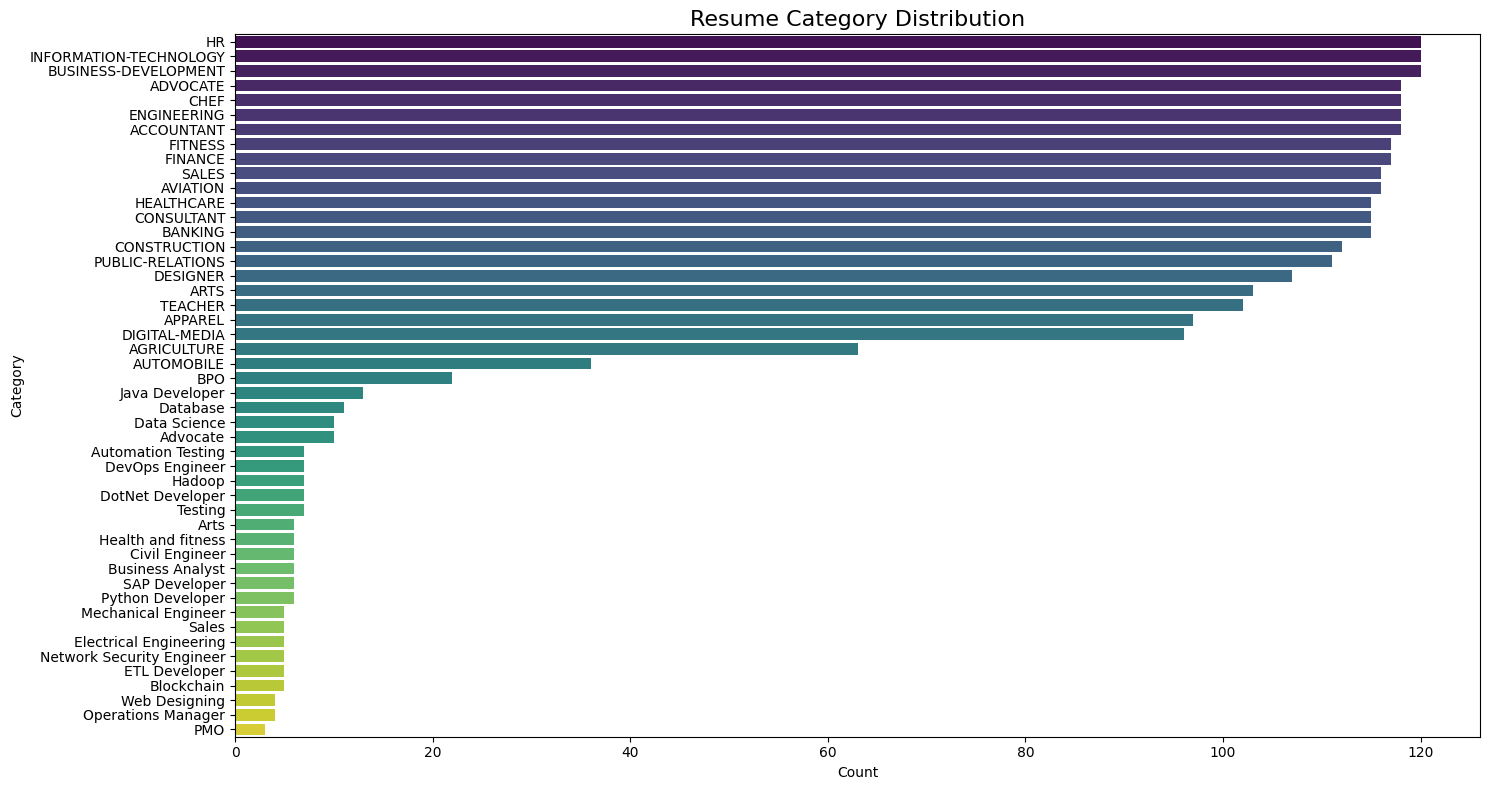

In [6]:
plt.figure(figsize=(15, 8))
counts = df_resume_merged["Category"].value_counts()
sns.barplot(y=counts.index, x=counts.values, palette="viridis")
plt.title("Resume Category Distribution", fontsize=16)
plt.xlabel("Count"); plt.ylabel("Category"); plt.tight_layout(); plt.show()

count    2648.000000
mean      787.202795
std       383.302222
min         0.000000
25%       635.000000
50%       745.000000
75%       921.000000
max      5190.000000
Name: Word_Count, dtype: float64


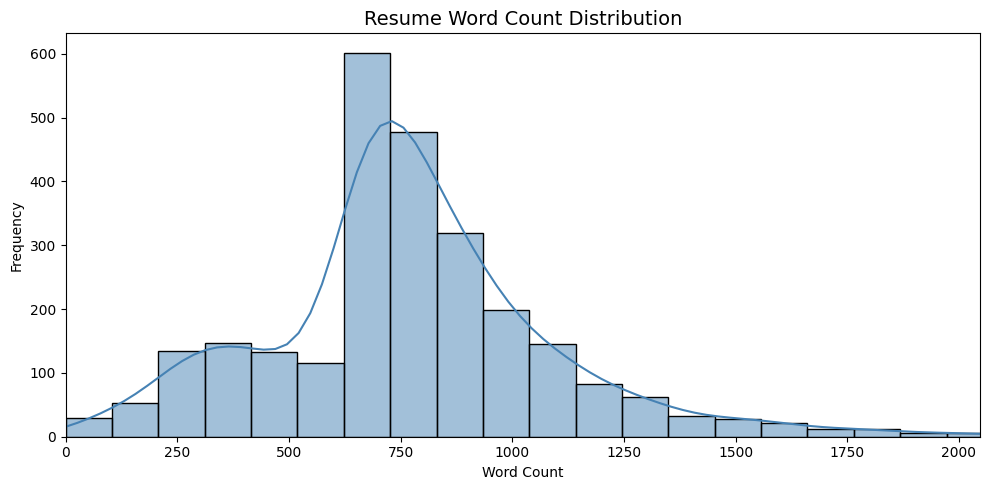

In [7]:
df_resume_merged["Word_Count"] = df_resume_merged["Resume"].apply(lambda x: len(str(x).split()))
print(df_resume_merged["Word_Count"].describe())
plt.figure(figsize=(10, 5))
sns.histplot(df_resume_merged["Word_Count"], bins=50, kde=True, color="steelblue")
plt.xlim(0, df_resume_merged["Word_Count"].quantile(0.99))
plt.title("Resume Word Count Distribution", fontsize=14)
plt.xlabel("Word Count"); plt.ylabel("Frequency"); plt.tight_layout(); plt.show()

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_15003/1903977245.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_resume_merged, x="Word_Count", y="Category", order=order, palette="viridis")


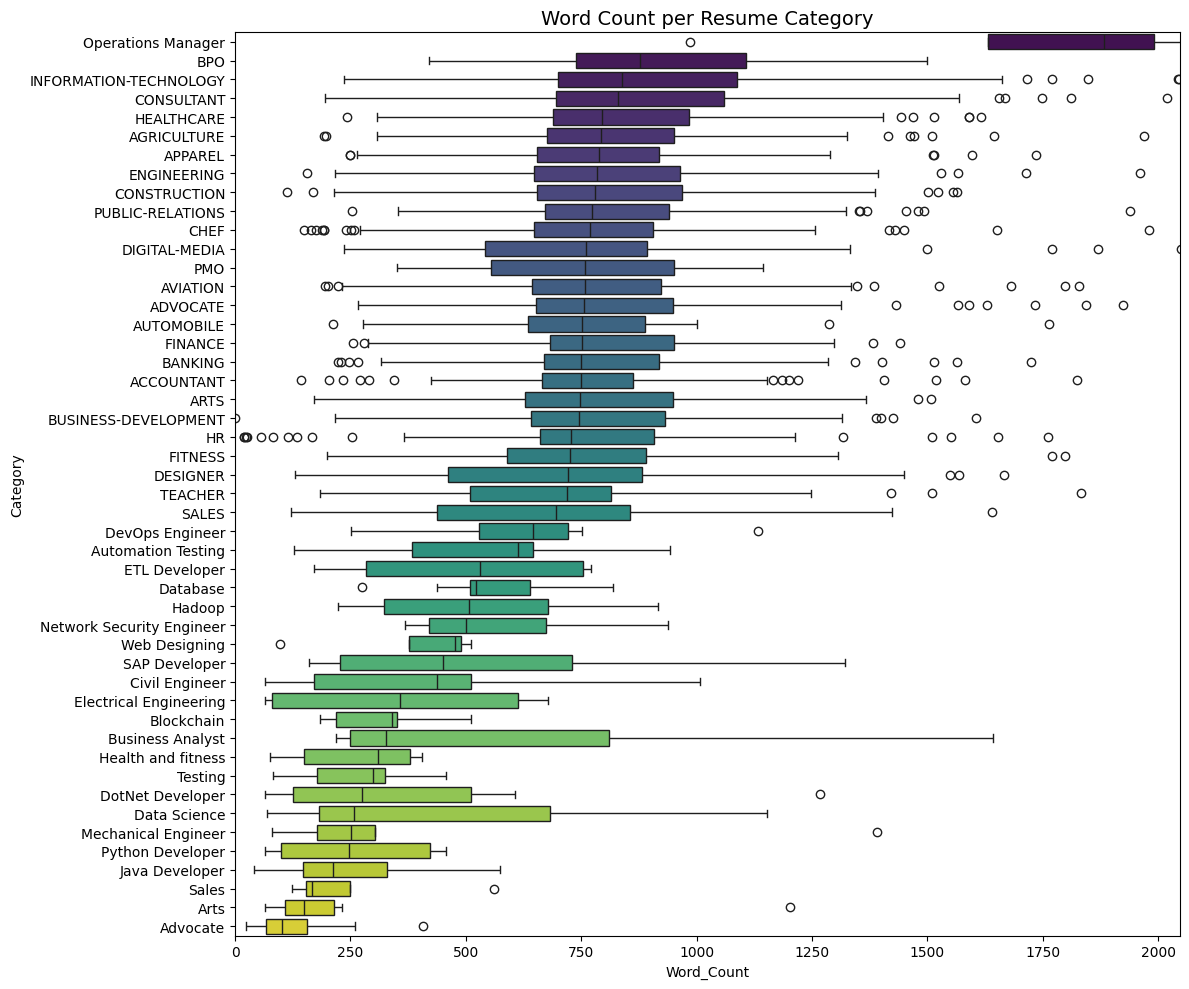

In [8]:
order = (df_resume_merged.groupby("Category")["Word_Count"]
         .median().sort_values(ascending=False).index)
plt.figure(figsize=(12, 10))
sns.boxplot(data=df_resume_merged, x="Word_Count", y="Category", order=order, palette="viridis")
plt.xlim(0, df_resume_merged["Word_Count"].quantile(0.99))
plt.title("Word Count per Resume Category", fontsize=14)
plt.tight_layout(); plt.show()

In [9]:
idx = random.randint(0, len(df_resume_merged) - 1)
print(f"Category: {df_resume_merged.iloc[idx]['Category']}")
print("-" * 50)
print(df_resume_merged.iloc[idx]["Resume"][:800])

Category: APPAREL
--------------------------------------------------
         SR. MANAGER       Summary     Over twenty-five years Management experience in Vendor Compliance, Product Integrity/Quality, Customer Support/Sales and Business Office Management.  I am a results-focused professional with the ability to manage multiple projects and meet deadlines in a fast paced environment.  Specific expertise includes: quality assurance, strategic planning, handling of large customer accounts, office management, vendor billing and invoicing, purchasing and payroll.       Highlights          Exceptional Customer Service Skills  Exceptional time management skills  Adaptable      Business and requirements analysis            Experience     10/2008   to   07/2012     Sr. Manager    Company Name   －   City  ,   State      Vendor Management and Product Integrity/Qualit


## 4. EDA — Job Description Corpus

Column schema, work mode distribution, and text length of `responsibilities`.

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    10000 non-null  int64
 1   title                 10000 non-null  str  
 2   department            10000 non-null  str  
 3   location              10000 non-null  str  
 4   required_skills       10000 non-null  str  
 5   preferred_skills      10000 non-null  str  
 6   education             10000 non-null  str  
 7   experience_required   10000 non-null  int64
 8   responsibilities      10000 non-null  str  
 9   employment_type       10000 non-null  str  
 10  company_name          10000 non-null  str  
 11  industry              10000 non-null  str  
 12  salary_range          10000 non-null  str  
 13  job_posted_date       10000 non-null  str  
 14  application_deadline  10000 non-null  str  
 15  work_mode             10000 non-null  str  
dtypes: int64(2), str

None


Work mode distribution:


work_mode
Hybrid    3421
Onsite    3292
WFH       3287
Name: count, dtype: int64

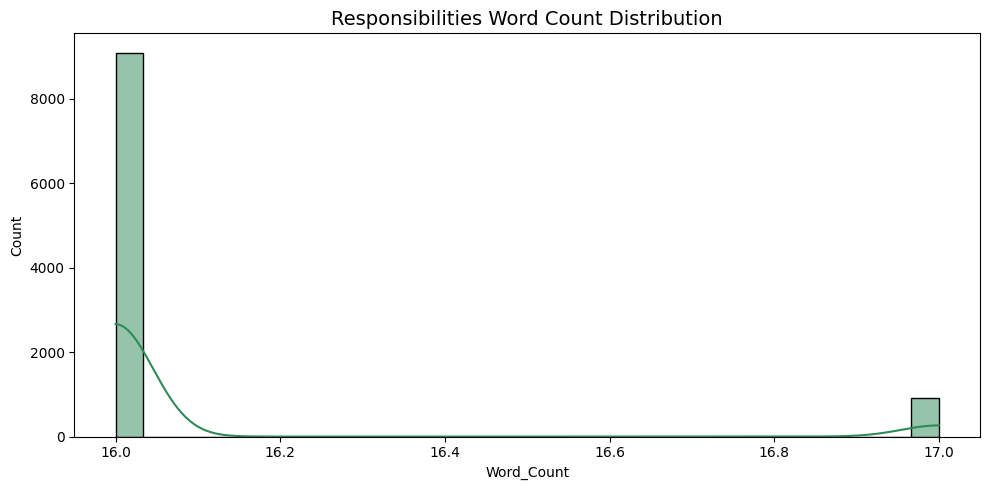

In [10]:
display(df_jobs.info())
print("\nWork mode distribution:"); display(df_jobs["work_mode"].value_counts())
df_jobs["Word_Count"] = df_jobs["responsibilities"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(df_jobs["Word_Count"], bins=30, kde=True, color="seagreen")
plt.title("Responsibilities Word Count Distribution", fontsize=14)
plt.tight_layout(); plt.show()

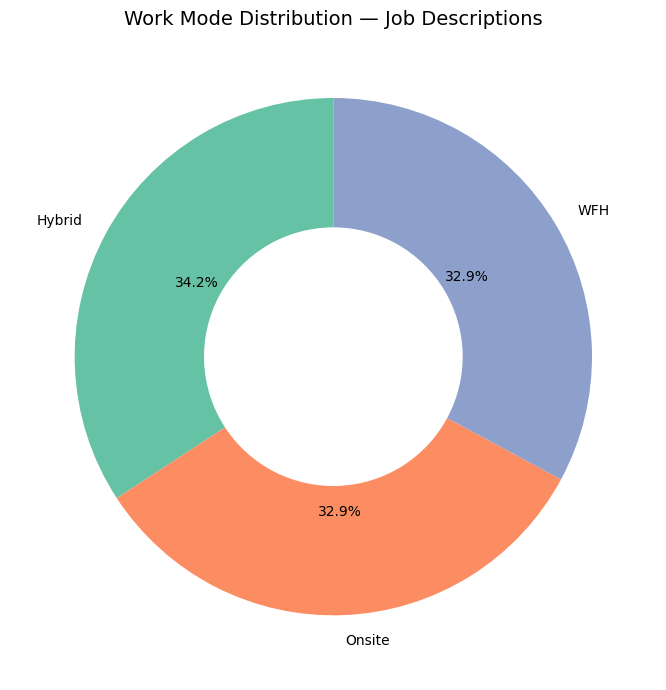

In [11]:
wm = df_jobs["work_mode"].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(wm.values, labels=wm.index, autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(width=0.5), colors=sns.color_palette("Set2", len(wm)))
ax.set_title("Work Mode Distribution — Job Descriptions", fontsize=14)
plt.tight_layout(); plt.show()

## 5. Export

Persist merged data for Notebook 02.

In [12]:
PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
df_resume_merged.to_csv(os.path.join(PROCESSED_DIR, "merged_resumes.csv"), index=False)
df_jobs.to_csv(os.path.join(PROCESSED_DIR, "job_descriptions.csv"), index=False)
print(f"Saved merged_resumes.csv  ({df_resume_merged.shape[0]:,} rows)")
print(f"Saved job_descriptions.csv ({df_jobs.shape[0]:,} rows)")

Saved merged_resumes.csv  (2,648 rows)
Saved job_descriptions.csv (10,000 rows)
